# Taller: Auditoría de Desempeño para Negocios Digitales:

## Parte 1: Análisis de datos sintéticos

En esta parte vamos a analizar un dataset de transacciones y determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop).

Vamos a generar una base de datos aleatoria, que simula la salida de un TPS.

In [22]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,App Móvil,Transferencia,337,Electrónica
1,1002,Web Desktop,Tarjeta Crédito,447,Electrónica
2,1003,App Móvil,Transferencia,84,Electrónica
3,1004,App Móvil,Tarjeta Crédito,110,Electrónica
4,1005,Web Desktop,PayPal,339,Hogar
5,1006,Web Desktop,PayPal,345,Moda
6,1007,Web Desktop,PayPal,485,Hogar
7,1008,App Móvil,Tarjeta Crédito,463,Moda
8,1009,Web Desktop,Tarjeta Crédito,466,Electrónica
9,1010,App Móvil,Transferencia,216,Hogar


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Buscamos saber cuál de las dos estrategias (M-Commerce o E-Commerce) es la más rentable.

Vamos a crear 4 KPIs para un MIS que nos permitan responder esta pregunta.

## Parte 2: KPIs para E-Commerce

Para esta parte vamos a utilizar los datos qu se encuentran en el repositorio en `/data/ecommerce.zip`

In [ ]:
import pandas as pd

In [15]:
data = pd.read_csv('Train.csv')

print("Dataset cargado correctamente")
print(f"Filas: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Dataset cargado correctamente
Filas: 10999 | Columnas: 12


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


### 1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. **Costo Promedio de Envío por Modo de Transporte (Mode of Shipment):** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. **Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. **Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

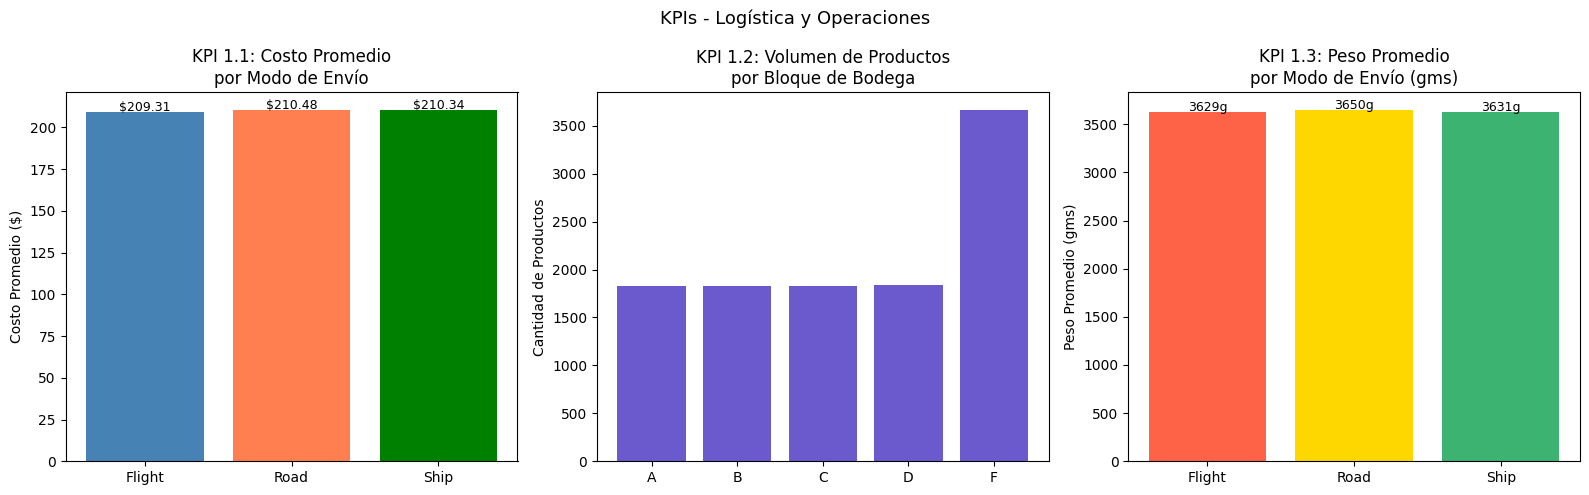

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KPIs - Logística y Operaciones', fontsize=13)

# KPI 1.1 - Costo promedio por modo de envío
costo_envio = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().round(2)
axes[0].bar(costo_envio.index, costo_envio.values, color=['steelblue', 'coral', 'green'])
axes[0].set_title('KPI 1.1: Costo Promedio\npor Modo de Envío')
axes[0].set_ylabel('Costo Promedio ($)')
for i, v in enumerate(costo_envio.values):
    axes[0].text(i, v + 0.5, f'${v}', ha='center', fontsize=9)

# KPI 1.2 - Volumen por bloque de bodega
volumen_bodega = data['Warehouse_block'].value_counts().sort_index()
axes[1].bar(volumen_bodega.index, volumen_bodega.values, color='slateblue')
axes[1].set_title('KPI 1.2: Volumen de Productos\npor Bloque de Bodega')
axes[1].set_ylabel('Cantidad de Productos')

# KPI 1.3 - Peso promedio por modo de envío
peso_envio = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().round(0)
axes[2].bar(peso_envio.index, peso_envio.values, color=['tomato', 'gold', 'mediumseagreen'])
axes[2].set_title('KPI 1.3: Peso Promedio\npor Modo de Envío (gms)')
axes[2].set_ylabel('Peso Promedio (gms)')
for i, v in enumerate(peso_envio.values):
    axes[2].text(i, v + 10, f'{int(v)}g', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

2.1. **Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable `Cost of the product` para entender el ticket promedio de la tienda de electrónica.

2.2. **Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (`Discount offered`) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

2.3. **Margen Teórico Relativo por Importancia del Producto:** Cruzar `Product importance` (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.

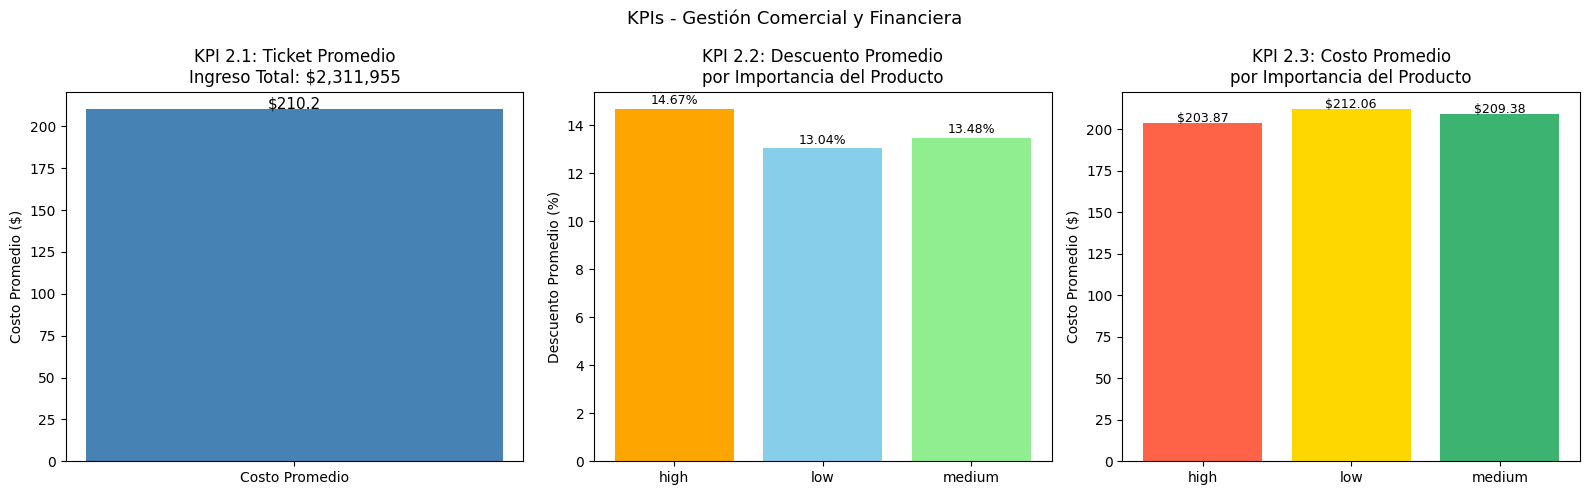

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KPIs - Gestión Comercial y Financiera', fontsize=13)

# KPI 2.1 - Ingreso total y costo promedio
ingreso_total = data['Cost_of_the_Product'].sum()
costo_promedio = data['Cost_of_the_Product'].mean().round(2)

axes[0].bar(['Costo Promedio'], [costo_promedio], color='steelblue')
axes[0].set_title(f'KPI 2.1: Ticket Promedio\nIngreso Total: ${ingreso_total:,}')
axes[0].set_ylabel('Costo Promedio ($)')
axes[0].text(0, costo_promedio + 0.5, f'${costo_promedio}', ha='center', fontsize=11)

# KPI 2.2 - Descuento promedio
descuento_promedio = data.groupby('Product_importance')['Discount_offered'].mean().round(2)
axes[1].bar(descuento_promedio.index, descuento_promedio.values, color=['orange', 'skyblue', 'lightgreen'])
axes[1].set_title('KPI 2.2: Descuento Promedio\npor Importancia del Producto')
axes[1].set_ylabel('Descuento Promedio (%)')
for i, v in enumerate(descuento_promedio.values):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)

# KPI 2.3 - Costo promedio por importancia del producto
costo_importancia = data.groupby('Product_importance')['Cost_of_the_Product'].mean().round(2)
axes[2].bar(costo_importancia.index, costo_importancia.values, color=['tomato', 'gold', 'mediumseagreen'])
axes[2].set_title('KPI 2.3: Costo Promedio\npor Importancia del Producto')
axes[2].set_ylabel('Costo Promedio ($)')
for i, v in enumerate(costo_importancia.values):
    axes[2].text(i, v + 0.5, f'${v}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

3.1. **Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable `Customer rating` (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

3.2. **Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de `Prior purchases` para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

3.3. **Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

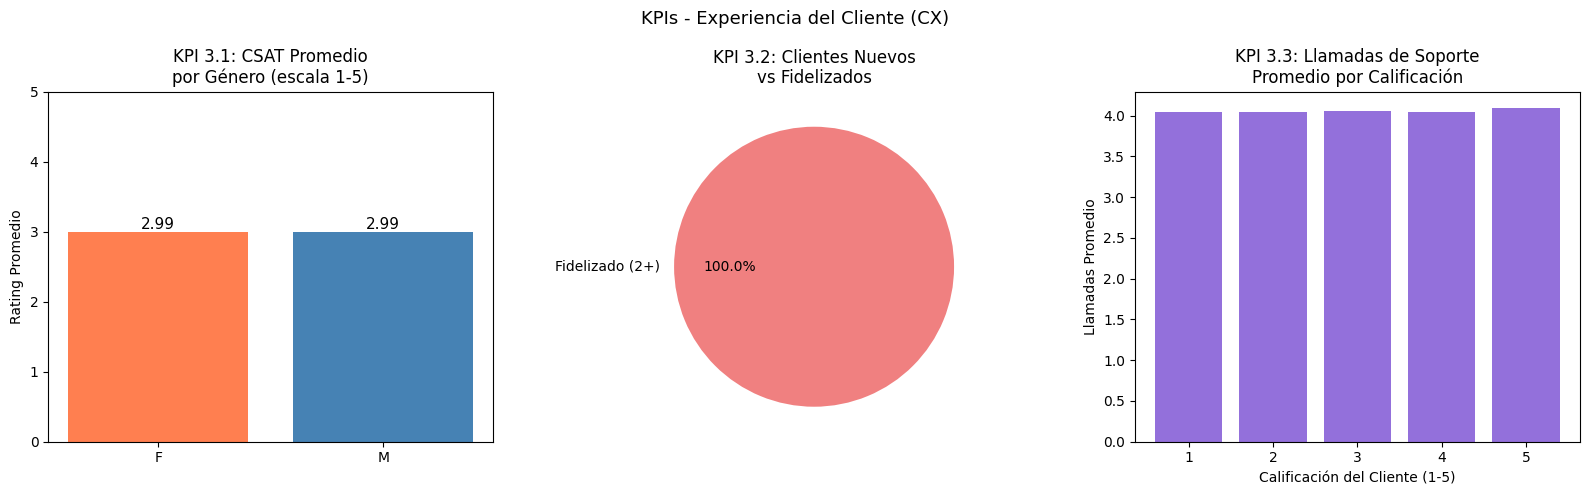

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KPIs - Experiencia del Cliente (CX)', fontsize=13)

# KPI 3.1 - Satisfacción promedio (CSAT) por género
csat_genero = data.groupby('Gender')['Customer_rating'].mean().round(2)
axes[0].bar(csat_genero.index, csat_genero.values, color=['coral', 'steelblue'])
axes[0].set_title('KPI 3.1: CSAT Promedio\npor Género (escala 1-5)')
axes[0].set_ylabel('Rating Promedio')
axes[0].set_ylim(0, 5)
for i, v in enumerate(csat_genero.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontsize=11)

# KPI 3.2 - Distribución de compras previas (clientes nuevos vs fidelizados)
data['Tipo_Cliente'] = data['Prior_purchases'].apply(
    lambda x: 'Nuevo (0-1)' if x <= 1 else 'Fidelizado (2+)'
)
tipo_cliente = data['Tipo_Cliente'].value_counts()
axes[1].pie(tipo_cliente.values, labels=tipo_cliente.index,
            autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
axes[1].set_title('KPI 3.2: Clientes Nuevos\nvs Fidelizados')

# KPI 3.3 - Llamadas de soporte promedio por calificación del cliente
llamadas_rating = data.groupby('Customer_rating')['Customer_care_calls'].mean().round(2)
axes[2].bar(llamadas_rating.index.astype(str), llamadas_rating.values, color='mediumpurple')
axes[2].set_title('KPI 3.3: Llamadas de Soporte\nPromedio por Calificación')
axes[2].set_xlabel('Calificación del Cliente (1-5)')
axes[2].set_ylabel('Llamadas Promedio')

plt.tight_layout()
plt.show()

### 4. KPIs de Método de Pago más Usado por Canal

Este KPI nos permite identificar qué método de pago prefieren los clientes
según el canal que usan (App Móvil o Web Desktop). En un negocio digital,
esta información es clave porque ayuda a la empresa a saber en qué
plataformas de cobro debe invertir y cuáles integrar mejor en su sistema.

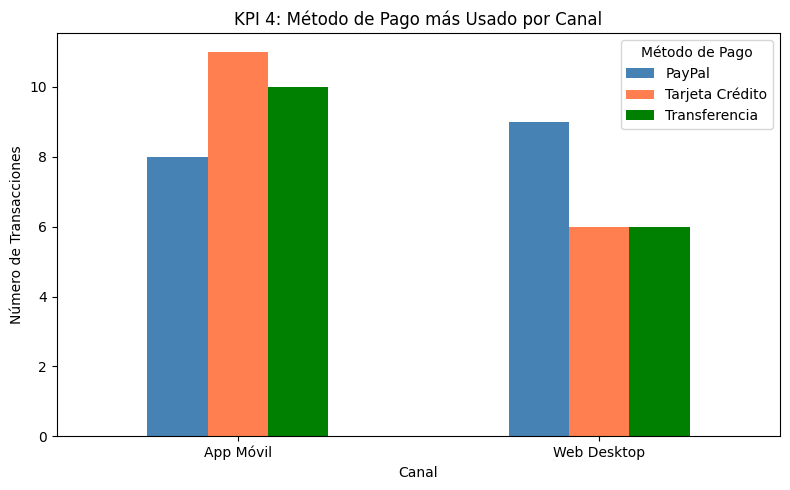

In [23]:
metodo_por_canal = df.groupby(['Canal', 'Metodo_Pago']).size().unstack()

metodo_por_canal.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'coral', 'green'])
plt.title('KPI 4: Método de Pago más Usado por Canal')
plt.xlabel('Canal')
plt.ylabel('Número de Transacciones')
plt.legend(title='Método de Pago')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusiones
---
**Logística:**
- Se puede ver qué modo de envío tiene mayor costo y mayor peso promedio, lo que ayuda a decidir si la empresa está optimizando bien su logística.
- Algunos bloques de bodega están más saturados que otros, lo que podría causar demoras.

**Comercial:**
- El ticket promedio nos da una idea del precio típico de los productos vendidos.
- Los descuentos no siempre se dan a los productos más importantes, lo cual puede ser una oportunidad de mejora en la estrategia de precios.

**Experiencia del cliente:**
- La satisfacción promedio está entre 2 y 4 en la mayoría de casos, lo que indica margen de mejora.
- Hay una mayor proporción de clientes fidelizados, lo que es positivo para el negocio.
- A mayor número de llamadas de soporte, generalmente la calificación del cliente tiende a ser más baja.

**Método de pago:**

Cruzar el canal de compra con el método de pago permite identificar la opción preferida de los clientes en cada plataforma (como PayPal en la App Móvil o tarjeta en Web Desktop) para optimizar su integración y eliminar errores. Este análisis es un ejemplo claro de cómo transformar los datos en información útil para la toma de decisiones estratégicas.